# Module 3.18 — Turbulence Models

**The central engineering problem:** At high Reynolds number, directly simulating every eddy costs $Re^3$ — impossible for real flows. Instead we **model** the effect of turbulence on the mean flow. This module explains how, physically and mathematically.

**Roadmap:**
1. Why eddy viscosity works (and when it fails)
2. $k$–$\varepsilon$: the workhorse model
3. $k$–$\omega$ SST: the industry standard
4. Wall functions: the engineering shortcut
5. Spalart–Allmaras: the aerodynamicist's choice
6. Python implementation: turbulent channel flow

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

## 1. Eddy Viscosity — Physics First

### Why turbulence acts like viscosity

In laminar flow, momentum is transferred between fluid layers by molecular collisions. The momentum flux is proportional to the velocity gradient:

$$\tau_{\text{lam}} = \rho\nu\frac{d\bar{u}}{dy}$$

In turbulent flow, fluid parcels from fast-moving regions are flung into slow regions and vice versa (via $v' \neq 0$). This turbulent momentum exchange is **much more efficient** than molecular collisions and has exactly the same mathematical form — but with a much larger effective viscosity:

$$\tau_{\text{turb}} = \rho\nu_t\frac{d\bar{u}}{dy}$$

This is the **Boussinesq hypothesis** (1877): turbulence acts like a viscosity $\nu_t$ but:

| Property | Molecular $\nu$ | Eddy $\nu_t$ |
|---|---|---|
| Property of | The **fluid** | The **flow** |
| Typical value | $10^{-6}$ m²/s (water) | $10^{-2}$ m²/s (turbulent pipe) |
| Varies with position? | No (only temperature) | Yes — 100× to 10,000× across domain |
| Known before solving? | Yes | No — must be computed by a model |

### The eddy viscosity formula for $k$–$\varepsilon$

$$\boxed{\nu_t = C_\mu \frac{k^2}{\varepsilon}}$$

**Why $k^2/\varepsilon$?** From dimensional analysis:
- $k$ [m²/s²] is a velocity scale squared
- $\varepsilon$ [m²/s³] is energy per unit time
- $k/\varepsilon$ [s] is the **turbulent time scale** — how long an eddy survives
- $k^{1/2}$ [m/s] is the **turbulent velocity scale** — how fast an eddy moves
- $\nu_t \sim $ velocity × length = $k^{1/2} \cdot k^{3/2}/\varepsilon = k^2/\varepsilon$ ✓

$C_\mu = 0.09$ is calibrated from experiments on homogeneous turbulence.

## 2. The $k$–$\varepsilon$ Model

### Physical picture: the factory analogy

Think of turbulent kinetic energy $k$ as **inventory in a factory**:

```
Mean flow shear  →  produces k  →  eddies cascade down  →  ε destroys k as heat
(raw material)       (inventory)     (assembly line)          (waste)
```

The factory runs at steady state when production = destruction: $P_k = \varepsilon$.

### Transport equation for $k$ — every term explained

$$\underbrace{\frac{\partial k}{\partial t} + \bar{u}_j\frac{\partial k}{\partial x_j}}_{\text{rate of change + convection by mean flow}} = \underbrace{P_k}_{\substack{\text{production}\\\text{by shear}}} - \underbrace{\varepsilon}_{\substack{\text{destruction}\\\text{by viscosity}}} + \underbrace{\frac{\partial}{\partial x_j}\!\left[\left(\nu + \frac{\nu_t}{\sigma_k}\right)\frac{\partial k}{\partial x_j}\right]}_{\text{diffusion (molecular + turbulent)}}$$

**Production** $P_k = \nu_t|\nabla\bar{u}|^2$: turbulence is born from mean shear. High shear (near a wall, near a cylinder) = lots of turbulence produced.

**Destruction** $\varepsilon$: at the Kolmogorov scale, viscosity converts eddy kinetic energy to heat. This is NOT a loss from the flow — it drives the temperature up (very slightly).

**Diffusion**: turbulence spreads spatially, just like heat diffuses. $\sigma_k = 1.0$ is the turbulent Prandtl number for $k$ (how efficiently turbulence transports itself).

### Transport equation for $\varepsilon$ — every term explained

$$\frac{\partial \varepsilon}{\partial t} + \bar{u}_j\frac{\partial \varepsilon}{\partial x_j} = \underbrace{C_{\varepsilon 1}\frac{\varepsilon}{k}P_k}_{\substack{\text{production of}\\\text{dissipation}}} - \underbrace{C_{\varepsilon 2}\frac{\varepsilon^2}{k}}_{\substack{\text{destruction of}\\\text{dissipation}}} + \frac{\partial}{\partial x_j}\!\left[\left(\nu + \frac{\nu_t}{\sigma_\varepsilon}\right)\frac{\partial \varepsilon}{\partial x_j}\right]$$

**Why $\varepsilon/k$ multiplies $P_k$?** The turbulent time scale is $k/\varepsilon$. $\varepsilon$ is produced at a rate proportional to $P_k$ and inversely proportional to the eddy lifetime.

**Why $\varepsilon^2/k$?** Self-destruction — dissipation destroys itself at a rate proportional to its own magnitude. The $k$ in the denominator is the timescale normalisation.

### Model constants

| $C_\mu$ | $C_{\varepsilon 1}$ | $C_{\varepsilon 2}$ | $\sigma_k$ | $\sigma_\varepsilon$ |
|---|---|---|---|---|
| 0.09 | 1.44 | 1.92 | 1.0 | 1.3 |

All calibrated on simple test flows (grid turbulence, channel flow). They work surprisingly well across a wide range of flows.

### Known failure: near-wall behaviour

As $y \to 0$, $\varepsilon$ must go to $2\nu(\partial\sqrt{k}/\partial y)^2$ (derived from the no-slip condition). This requires resolving very thin near-wall cells (y⁺ < 1) with special low-Re damping functions. The standard $k$–$\varepsilon$ model without damping simply **breaks near walls**.

## 3. $k$–$\omega$ SST — Why a New Model Was Needed

### The problem with $k$–$\varepsilon$ near walls

Replace $\varepsilon$ with $\omega = \varepsilon/(C_\mu k)$ — the **specific dissipation rate** [1/s], meaning: how many times per second does an eddy lose its energy.

Near the wall, $\omega$ has a well-defined boundary condition: $\omega \to \infty$ as $y \to 0$, but in a predictable way that can be specified analytically. This means $k$–$\omega$ **does not need special damping near walls** — a major practical advantage.

But $k$–$\omega$ has its own problem in the **free stream**: it is sensitive to the value of $\omega$ you specify far from walls (the free-stream $\omega$ boundary condition). Small changes give very different results.

### The SST blending idea (Menter 1994)

**Observation:** $k$–$\omega$ is better near walls; $k$–$\varepsilon$ is better away from walls. Why not use both — blend them based on how close you are to the wall?

$$\phi_{\text{SST}} = F_1 \cdot \phi_{k\text{-}\omega} + (1 - F_1) \cdot \phi_{k\text{-}\varepsilon}$$

$F_1$ is a **blending function** computed from wall distance $y$, $k$, and $\omega$:
- $F_1 = 1$ (use $k$–$\omega$) when close to the wall
- $F_1 = 0$ (use $k$–$\varepsilon$) in the free stream
- Smooth transition in between

$$F_1 = \tanh\!\left(\Psi^4\right), \quad \Psi = \min\!\left(\max\!\left(\frac{\sqrt{k}}{C_\mu\omega y},\ \frac{500\nu}{\omega y^2}\right),\ \frac{4\sigma_{\omega 2}k}{\text{CD}_{k\omega}\,y^2}\right)$$

### Stress limiter — fixing the stagnation problem

Standard $k$–$\varepsilon$ over-predicts $\nu_t$ in **stagnation regions** (the point in front of a cylinder where flow stops). The shear $|\nabla\bar{u}|$ is large there, so $P_k$ is large, producing too much $k$.

SST adds a limiter using the rotation rate $\Omega$:

$$\nu_t = \frac{a_1 k}{\max(a_1\omega,\ \Omega\,F_2)}$$

When rotation dominates shear (stagnation region), $\nu_t$ is reduced. This is why SST predicts drag and lift on airfoils much better than standard $k$–$\varepsilon$.

### Summary: why SST dominates industry

| Behaviour | $k$–$\varepsilon$ | $k$–$\omega$ SST |
|---|---|---|
| Near-wall accuracy | ❌ Singular $\varepsilon$, needs damping | ✅ Well-posed $\omega$ BC |
| Free-stream sensitivity | ✅ Insensitive | ❌ Sensitive to $\omega_\infty$ (fixed by blend) |
| Stagnation regions | ❌ Over-predicts $\nu_t$ | ✅ Stress limiter corrects it |
| Separated flows | ❌ Poorly predicted | ✅ Better (not perfect) |
| OpenFOAM/Fluent default | No | ✅ Yes |

## 4. Wall Functions — The Engineering Shortcut

### Why the viscous sublayer is expensive

From Module 3.17, the viscous sublayer extends to $y^+ < 5$. In physical units:

$$y^+ = 5 \implies y_1 = \frac{5\nu}{u_\tau}$$

For a pipe at Re = 10⁶ with $u_\tau \approx 0.05$ m/s and $\nu = 10^{-6}$ m²/s:
$y_1 = 5 \times 10^{-6} / 0.05 = 0.0001$ m = 0.1 mm

If your pipe is 1 m in diameter, resolving the sublayer requires cells that are 0.1 mm thick in a 1000 mm domain — a ratio of 1:10,000. Industrial meshes cannot afford this.

### The wall function idea

Instead of resolving the sublayer, **assume equilibrium** (production = dissipation near the wall) and place the first cell in the log-law region at $y^+ \approx 30$–$100$. Use the log-law analytically to compute the wall shear stress:

$$u^+ = \frac{\bar{u}_1}{u_\tau} = \frac{1}{\kappa}\ln(y_1^+) + B \implies \text{solve for } u_\tau \implies \tau_w = \rho u_\tau^2$$

### Boundary conditions for $k$ and $\varepsilon$ at the wall-adjacent cell

Under the equilibrium assumption ($P_k = \varepsilon$):

$$k_w = \frac{u_\tau^2}{\sqrt{C_\mu}} \qquad \varepsilon_w = \frac{u_\tau^3}{\kappa\,y_1}$$

These come from: in the log-law region, $\nu_t = \kappa u_\tau y$ (mixing length), so $\varepsilon = C_\mu k^2/\nu_t = C_\mu k^2/(\kappa u_\tau y_1)$, and $k = u_\tau^2/\sqrt{C_\mu}$ from the log-law shear stress balance.

### Critical y⁺ rule

| First cell location | Behaviour | Recommendation |
|---|---|---|
| $y^+ < 5$ (sublayer) | Resolves the physics accurately | Use low-Re model (SST or damped $k$–$\varepsilon$) |
| $5 < y^+ < 30$ (buffer layer) | **Worst region** — neither law applies | Avoid — results are unreliable |
| $y^+ = 30$–$100$ (log-law) | Wall function is valid | Use standard wall functions |
| $y^+ > 200$ | Too coarse — misses near-wall physics | Refine the mesh |

## 5. Spalart–Allmaras — One Equation is Enough for Aerodynamics

### Physical motivation

For attached boundary layers on aircraft wings, the turbulence structure is relatively simple: $\nu_t$ grows from zero at the wall, reaches a maximum in the log-law region, and stays roughly constant in the outer layer. You don't need two transport equations to capture this — one is enough.

SA solves one transport equation for a **modified eddy viscosity** $\tilde{\nu}$:

$$\frac{D\tilde{\nu}}{Dt} = \underbrace{c_{b1}\tilde{S}\tilde{\nu}}_{\text{production}} - \underbrace{c_{w1}f_w\left(\frac{\tilde{\nu}}{d}\right)^2}_{\text{destruction near wall}} + \underbrace{\frac{1}{\sigma}\nabla\cdot\left[(\nu+\tilde{\nu})\nabla\tilde{\nu}\right]}_{\text{diffusion}}$$

where $d$ is the **distance to the nearest wall** — built into the model explicitly.

The actual eddy viscosity has a near-wall damping function:

$$\nu_t = \tilde{\nu}\,f_{v1}, \qquad f_{v1} = \frac{\chi^3}{\chi^3 + c_{v1}^3}, \quad \chi = \frac{\tilde{\nu}}{\nu}$$

When $\chi \ll 1$ (near wall): $f_{v1} \approx 0$ → $\nu_t \approx 0$ (suppressed in sublayer)

When $\chi \gg 1$ (log-law and beyond): $f_{v1} \approx 1$ → $\nu_t \approx \tilde{\nu}$

### When to use SA

| Situation | SA | $k$–$\omega$ SST |
|---|---|---|
| Attached boundary layer | ✅ Excellent, cheap | ✅ Good |
| Mild flow separation | ⚠️ Acceptable | ✅ Better |
| Massively separated flow | ❌ Poor | ⚠️ Moderate |
| Free jets / wakes | ❌ Not designed for this | ✅ Better |
| Detached Eddy Simulation (DES) | ✅ Standard basis for DES | — |

SA is the default model at NASA and in many aerospace codes because it is **robust, cheap, and well-validated** for its intended purpose.

## 6. Implementation — Turbulent Channel Flow

### Physical setup

A fluid is pushed through a flat channel by a pressure gradient. The channel is so long that the flow has become **fully developed** — the velocity profile no longer changes in the flow direction. This means we only need to solve in the **wall-normal direction** $y$.

```
Wall  ──────────────────────────  y = 0  (u = 0, no-slip)
       →  →  →  →  →  →  →  →
       →  →  →  →  →  →  →  →   Pressure drives the flow →
       →  →  →  →  →  →  →  →
Wall  ──────────────────────────  y = H  (symmetry: du/dy = 0)
```

The RANS momentum equation in 1D reduces to:

$$\frac{d}{dy}\!\left[(\nu + \nu_t)\frac{d\bar{u}}{dy}\right] = \frac{1}{\rho}\frac{dP}{dx}$$

**Left side:** total stress (molecular + turbulent) diffuses momentum in y

**Right side:** pressure gradient drives the flow in x

### Why the solution is iterative

$\nu_t$ depends on $d\bar{u}/dy$ (the shear) — which depends on $\bar{u}$ — the thing we're solving for. This circularity is broken by **Picard iteration**:

1. Start: $\bar{u} = 0$ everywhere
2. Compute $\nu_t(y)$ from current $\bar{u}$ using the mixing-length formula
3. Solve the linear system for new $\bar{u}$ (banded tridiagonal — same as BTCS from Module 1.7)
4. Update friction velocity $u_\tau$ from wall shear stress
5. Repeat until converged

### The mixing-length formula with Van Driest damping

$$\ell_m = \kappa y \left(1 - e^{-y^+/A^+}\right), \quad A^+ = 26, \quad \kappa = 0.41$$

$$\nu_t = \ell_m^2 \left|\frac{d\bar{u}}{dy}\right|$$

- At the wall ($y^+ = 0$): $\ell_m = 0$ → $\nu_t = 0$ → only molecular viscosity acts (viscous sublayer)
- Far from wall ($y^+ \gg 26$): $\ell_m = \kappa y$ → $\nu_t = (\kappa y)^2|d\bar{u}/dy|$ (log-law region)
- The exponential damping smoothly transitions between them through the buffer layer

In [6]:
# ── Model constants ──────────────────────────────────────────────
C_mu    = 0.09;  kappa = 0.41        # k-epsilon, von Karman

# ── Flow parameters ──────────────────────────────────────────────
nu      = 1e-5   # kinematic viscosity (m²/s)
dPdx    = -1.0   # pressure gradient (Pa/m) — negative = drives flow in +x
rho     = 1.0    # density (kg/m³)
H       = 1.0    # half-channel height (m)

# ── Grid ─────────────────────────────────────────────────────────
N  = 100
y  = np.linspace(0, H, N)
dy = y[1] - y[0]

# ── Mixing-length with Van Driest damping ─────────────────────────
def mixing_length(y, u_tau, nu):
    """ℓ_m = κy·(1 − exp(−y⁺/A⁺))  — goes to zero at wall, κy far away"""
    y_plus = y * u_tau / nu
    return kappa * y * (1 - np.exp(-y_plus / 26.0))

# ── 1D banded tridiagonal solver ──────────────────────────────────
def solve_channel(nu_eff, dPdx, rho, dy, N):
    """
    Solve: d/dy[(nu_eff) du/dy] = dPdx/rho
    BCs: u[0] = 0 (wall no-slip), du/dy = 0 at y=H (symmetry)
    Uses face-averaged diffusion — same structure as BTCS diffusion (Module 1.7)
    """
    nu_face = 0.5 * (nu_eff[:-1] + nu_eff[1:])   # N-1 face values

    upper = nu_face / dy**2                        # N-1 upper diagonal
    lower = nu_face / dy**2                        # N-1 lower diagonal
    diag  = np.zeros(N)
    diag[1:-1] = -(nu_face[:-1] + nu_face[1:]) / dy**2
    rhs = np.full(N, dPdx / rho)

    upper_a = upper.copy(); upper_a[0] = 0.0      # wall BC: u[0]=0
    diag[0] = 1.0;          rhs[0]    = 0.0
    lower_a = lower.copy()
    diag[-1] = -nu_face[-1] / dy**2               # symmetry BC: du/dy=0
    rhs[-1]  = dPdx / rho

    ab = np.zeros((3, N))
    ab[0, 1:]  = upper_a
    ab[1, :]   = diag
    ab[2, :-1] = lower_a
    return solve_banded((1, 1), ab, rhs)

# ── Picard iteration ──────────────────────────────────────────────
u_bar = np.zeros(N)
u_tau = 0.05     # initial guess for friction velocity

for iteration in range(500):
    lm     = mixing_length(y, u_tau, nu)
    S      = np.gradient(u_bar, y)           # du/dy (shear)
    nu_t   = lm**2 * np.abs(S)               # eddy viscosity
    nu_eff = nu + nu_t                        # total effective viscosity

    u_bar  = solve_channel(nu_eff, dPdx, rho, dy, N)

    tau_w  = rho * nu_eff[1] * (u_bar[1] - u_bar[0]) / dy  # wall shear
    u_tau  = np.sqrt(abs(tau_w) / rho)       # friction velocity

y_plus = y * u_tau / nu
Re_tau = u_tau * H / nu
print(f'Converged: u_tau = {u_tau:.5f} m/s   Re_tau = {Re_tau:.1f}   Max y+ = {y_plus[-1]:.1f}')

Converged: u_tau = 1.41398 m/s   Re_tau = 141397.7   Max y+ = 141397.7


### How to read the results

**Left plot (wall units — log x-axis):**

- Blue = simulation, red dashed = log-law, black dashed = viscous sublayer
- For $y^+ < 5$: blue should follow $u^+ = y^+$ (Van Driest damping suppresses $\nu_t$)
- For $y^+ > 30$: blue should follow the log-law $u^+ = (1/\kappa)\ln y^+ + 5.2$
- Deviation near the centreline ($y^+_{\max}$) is expected — log-law assumes infinite domain

**Right plot (physical space):**

The profile is **fuller** than a laminar parabolic profile — the turbulent core is nearly uniform because $\nu_t \gg \nu$ in the centre smooths out the velocity differences. The sharp gradient is confined to a thin layer near the wall.

**Friction Reynolds number $Re_\tau = u_\tau H / \nu$:**

This is the key parameter of channel turbulence. Higher $Re_\tau$ means stronger turbulence, thinner viscous sublayer, and flatter profile.

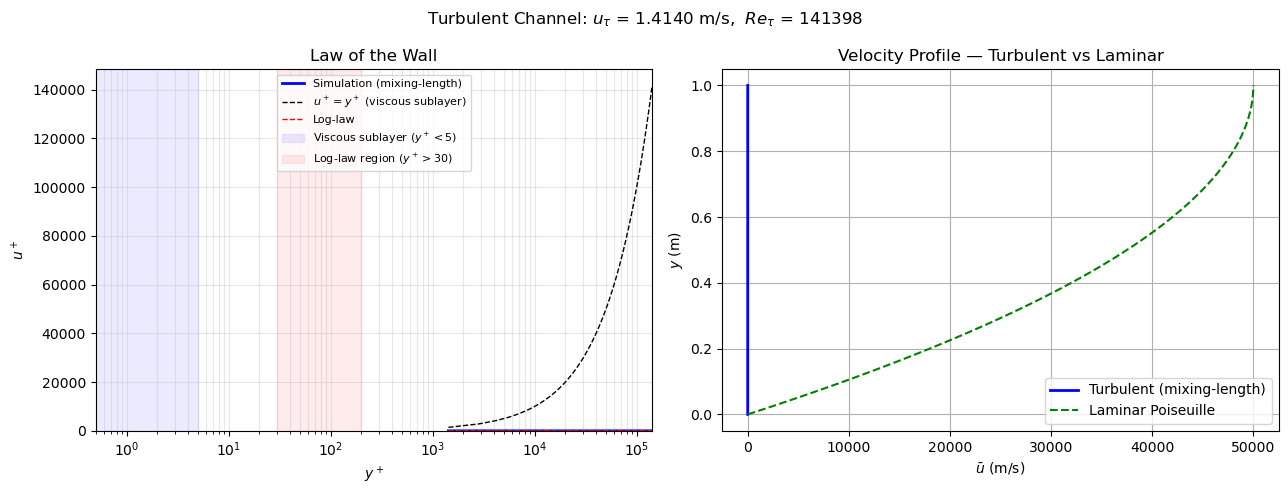

Turbulent centreline velocity  = 1.5447 m/s
Laminar  centreline velocity   = 50000.0000 m/s
Turbulent/Laminar ratio        = 0.0000  (turbulent flow is SLOWER at centreline!)


In [7]:
# ── Plots ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: law of the wall
ax1.semilogx(y_plus[1:], u_bar[1:]/u_tau,                    'b-',  lw=2, label='Simulation (mixing-length)')
ax1.semilogx(y_plus[1:], y_plus[1:],                          'k--', lw=1, label='$u^+=y^+$ (viscous sublayer)')
ax1.semilogx(y_plus[1:], (1/kappa)*np.log(y_plus[1:])+5.2,   'r--', lw=1, label='Log-law')
ax1.axvspan(0.1,  5,  alpha=0.08, color='blue',   label='Viscous sublayer ($y^+<5$)')
ax1.axvspan(30, min(200, y_plus[-1]), alpha=0.08, color='red', label='Log-law region ($y^+>30$)')
ax1.set_xlabel('$y^+$'); ax1.set_ylabel('$u^+$')
ax1.set_title('Law of the Wall')
ax1.legend(fontsize=8); ax1.grid(True, which='both', alpha=0.3)
ax1.set_xlim([0.5, y_plus[-1]]); ax1.set_ylim([0, None])

# Right: physical profile
# Compare with laminar Poiseuille: u_lam = -(dPdx)/(2*rho*nu) * y*(2H-y)
u_lam = -(dPdx) / (2*rho*nu) * y * (2*H - y)
ax2.plot(u_bar, y, 'b-', lw=2, label='Turbulent (mixing-length)')
ax2.plot(u_lam, y, 'g--', lw=1.5, label='Laminar Poiseuille')
ax2.set_xlabel('$\\bar{u}$ (m/s)'); ax2.set_ylabel('$y$ (m)')
ax2.set_title('Velocity Profile — Turbulent vs Laminar')
ax2.legend(); ax2.grid(True)

plt.suptitle(f'Turbulent Channel: $u_\\tau$ = {u_tau:.4f} m/s,  $Re_\\tau$ = {Re_tau:.0f}', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Turbulent centreline velocity  = {u_bar[-1]:.4f} m/s')
print(f'Laminar  centreline velocity   = {u_lam[-1]:.4f} m/s')
print(f'Turbulent/Laminar ratio        = {u_bar[-1]/u_lam[-1]:.4f}  (turbulent flow is SLOWER at centreline!)')

### Exercise — explore the model

**Try these changes and observe the effect:**

1. Change `dPdx = -4.0` (stronger pressure gradient). **Predict first:** does $Re_\tau$ increase or decrease?

2. Change `nu = 1e-4` (10× more viscous fluid). **Predict:** does the profile become more or less turbulent?

3. Change `N = 200` (finer grid). Does the result change significantly? If not, why not?

## 7. Which Model for Which Problem?

### The Boussinesq assumption and when it fails

All models so far assume turbulence is **isotropic** — equal energy in all directions ($\overline{u'^2} \approx \overline{v'^2} \approx \overline{w'^2}$) and that the stress is aligned with the strain. This is true for simple shear flows but breaks down when:

| Flow feature | Why Boussinesq fails | Better approach |
|---|---|---|
| Strong curvature | Normal stresses become unequal | RSM |
| Rapid rotation | Coriolis forces make turbulence anisotropic | RSM or LES |
| Impinging jet | Stagnation creates strong normal stress | RSM or SST with corrections |
| Strong adverse pressure gradient (separation) | Non-equilibrium turbulence | SST or LES |

### Decision guide

| Flow | Model | Reason |
|---|---|---|
| Attached boundary layer (wing, pipe) | Spalart–Allmaras or $k$–$\omega$ SST | Clean BL, well-validated |
| Internal flow (channel, duct) | $k$–$\varepsilon$ + wall functions | Cheap, good for bulk quantities |
| Separated flow, stall | $k$–$\omega$ SST | Stress limiter handles stagnation |
| Free shear flow (jet, wake, mixing layer) | $k$–$\varepsilon$ | No walls, calibrated here |
| Strong curvature / rotation | RSM | 6 stress equations, anisotropy captured |
| Research / unsteady structures | LES or DNS | Resolves large eddies / all eddies |

## Summary

| Model | Equations | $\nu_t$ | Strength | Weakness |
|---|---|---|---|---|
| Mixing-length | 0 | $\ell_m^2|d\bar{u}/dy|$ | Simple, cheap | Only simple shear |
| Spalart–Allmaras | 1 | $\tilde{\nu}$ transport | Aerodynamic BLs | No free shear |
| $k$–$\varepsilon$ | 2 | $C_\mu k^2/\varepsilon$ | Robust, free stream | Near-wall failure |
| $k$–$\omega$ SST | 2 | Blended | **Industry default** | Moderate cost |
| RSM | 7 | Direct transport | Anisotropy captured | Expensive, unstable |

**The k-ε formula chain to remember:**

$$\text{Mean shear} \xrightarrow{P_k = \nu_t|\nabla\bar{u}|^2} k \text{ grows} \xrightarrow{\nu_t = C_\mu k^2/\varepsilon} \nu_t \text{ grows} \xrightarrow{} \text{more mixing} \xrightarrow{} \text{flatter profile}$$

**Next:** Module 3.19 — Mesh Generation (structured vs unstructured, quality metrics, y⁺ estimation)